In [2]:
from langgraph.graph import StateGraph , START , END
from typing import TypedDict,Annotated,Literal


In [17]:
class QuadState(TypedDict):
    a: float
    b: float
    c: float

    equation:str
    discriminant: float
    result: str

In [18]:
def show_equation(state:QuadState) -> QuadState:
    a = state['a']
    b = state['b']
    c = state['c']

    equation = f"{a}x^2 + {b}x + {c} = 0"
    return {'equation': equation}

In [19]:
def calculate_discriminant(state:QuadState) -> QuadState:
    a = state['a']
    b = state['b']
    c = state['c']

    discriminant = b**2 - 4*a*c
    return {'discriminant': discriminant}

In [20]:
def real_roots(state: QuadState) -> QuadState:
    a = state['a']
    b = state['b']
    d = state['discriminant']

    root1 = (-b + d**0.5) / (2 * a)
    root2 = (-b - d**0.5) / (2 * a)
    result = f"Two real roots are: {root1} and {root2}"

    return {'result': result}


def repeated_root(state: QuadState) -> QuadState:
    a = state['a']
    b = state['b']
    d = state['discriminant']

    root = -b / (2 * a)
    result = f"Only repeated root is: {root}"

    return {'result': result}


def complex_roots(state: QuadState) -> QuadState:
    a = state['a']
    b = state['b']
    d = state['discriminant']

    real_part = -b / (2 * a)
    imaginary_part = (abs(d) ** 0.5) / (2 * a)

    result = (
        f"Two complex roots are: "
        f"{real_part} + {imaginary_part}i and "
        f"{real_part} - {imaginary_part}i"
    )

    return {'result': result}




In [24]:
def check_condition(state: QuadState) -> Literal['real_roots', 'repeated_root', 'complex_roots']:
    d = state['discriminant']

    if d > 0:
        return "real_roots"
    elif d == 0:
        return "repeated_root"
    else:
        return "complex_roots"

In [30]:
#graph
graph = StateGraph(QuadState)

graph.add_node('show_equation',show_equation)
graph.add_node("calculate_discriminant",calculate_discriminant)

graph.add_node("real_roots",real_roots)
graph.add_node("repeated_root",repeated_root)
graph.add_node("complex_roots",complex_roots)

graph.add_edge(START,'show_equation')
graph.add_edge('show_equation','calculate_discriminant')

graph.add_conditional_edges('calculate_discriminant',check_condition)
graph.add_edge('real_roots',END)
graph.add_edge('repeated_root',END)
graph.add_edge('complex_roots',END)

workflow = graph.compile()



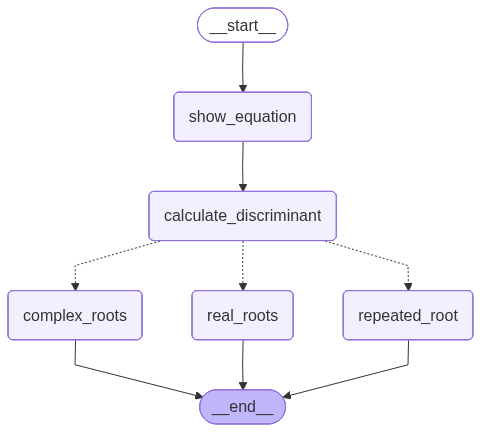

In [31]:
workflow


In [29]:
initial_state = {
    'a': 1,
    'b': -3,
    'c': 2
}
workflow.invoke(initial_state)

{'a': 1,
 'b': -3,
 'c': 2,
 'equation': '1x^2 + -3x + 2 = 0',
 'discriminant': 1,
 'result': 'Two real roots are: 2.0 and 1.0'}